# Phase 10 — Final Untouched Test Evaluation

This notebook performs the **first and only final evaluation** of the selected canonical
model on the untouched test split.

It:

1. Loads `results/final_model/best_model.json`.
2. Reconstructs the exact selected ResNet18 configuration.
3. Loads `results/final_model/best_model.pth`.
4. Applies deterministic test preprocessing only.
5. Runs one inference pass over `data/splits/test.csv`.
6. Saves final metrics, predictions, confusion matrices, confidence analysis,
   error examples, metadata hashes, and a reproducibility manifest.

> **Methodological freeze:** no training, tuning, threshold adjustment, checkpoint
> comparison, or model replacement is performed in this notebook.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import random
import sys
from collections import OrderedDict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn

from IPython.display import Markdown, display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate

        marker_count = sum(
            (candidate / marker).exists()
            for marker in ["src", "data", "results", "notebooks"]
        )

        if marker_count >= 3:
            return candidate

    return start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from src.datasets.horse_dataset import HorseGrimaceDataset

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

Project root: /home/uteam6/computer-vision-equine-grimace-scale
PyTorch version: 2.5.1+cu121
scikit-learn version: 1.9.0


In [2]:
SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")
print(f"Random seed: {SEED}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
Random seed: 42
GPU: Quadro RTX 4000


In [3]:
TEST_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "test.csv"
)

FINAL_MODEL_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_model"
)

FINAL_CHECKPOINT = (
    FINAL_MODEL_DIR
    / "best_model.pth"
)

FINAL_METADATA = (
    FINAL_MODEL_DIR
    / "best_model.json"
)

FINAL_EVALUATION_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
)

FIGURES_DIR = FINAL_EVALUATION_DIR / "figures"

FINAL_METRICS_JSON = (
    FINAL_EVALUATION_DIR
    / "final_test_metrics.json"
)

for required_path in [
    TEST_CSV,
    FINAL_CHECKPOINT,
    FINAL_METADATA,
]:
    assert required_path.exists(), (
        f"Required file is missing: {required_path}"
    )

FINAL_EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# This guard prevents an accidental second final evaluation after results exist.
# Leave False for the official run.
ALLOW_RERUN = False

if FINAL_METRICS_JSON.exists() and not ALLOW_RERUN:
    raise RuntimeError(
        "Final test results already exist at "
        f"{FINAL_METRICS_JSON}. "
        "The Phase 10 evaluation is frozen. "
        "Do not rerun it unless there is a documented technical reason. "
        "For a justified rerun only, set ALLOW_RERUN = True."
    )

print(f"Test CSV:        {TEST_CSV}")
print(f"Final checkpoint:{FINAL_CHECKPOINT}")
print(f"Final metadata:  {FINAL_METADATA}")
print(f"Output folder:   {FINAL_EVALUATION_DIR}")

Test CSV:        /home/uteam6/computer-vision-equine-grimace-scale/data/splits/test.csv
Final checkpoint:/home/uteam6/computer-vision-equine-grimace-scale/results/final_model/best_model.pth
Final metadata:  /home/uteam6/computer-vision-equine-grimace-scale/results/final_model/best_model.json
Output folder:   /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation


In [4]:
def read_json(path: Path) -> dict[str, Any]:
    with path.open(
        "r",
        encoding="utf-8",
    ) as input_file:
        return json.load(input_file)


def nested_value(
    data: Any,
    keys: Iterable[str],
) -> Any:
    if not isinstance(data, dict):
        return None

    for key in keys:
        if key in data and data[key] is not None:
            return data[key]

    for value in data.values():
        if isinstance(value, dict):
            result = nested_value(
                value,
                keys,
            )

            if result is not None:
                return result

    return None


metadata = read_json(
    FINAL_METADATA
)

MODEL_FAMILY = str(
    nested_value(
        metadata,
        ["model_family", "architecture", "model_name"],
    )
    or "resnet18"
).lower()

TRAINING_MODE = str(
    nested_value(
        metadata,
        ["training_mode", "selected_training_mode"],
    )
    or "fine_tuned"
).lower()

NUM_CLASSES = int(
    nested_value(
        metadata,
        ["num_classes"],
    )
    or 3
)

CLASS_NAMES = list(
    nested_value(
        metadata,
        ["class_names"],
    )
    or [
        "No Pain",
        "Moderate Pain",
        "Severe Pain",
    ]
)

DROPOUT = float(
    nested_value(
        metadata,
        ["dropout", "dropout_rate"],
    )
    or 0.5
)

IMAGE_SIZE = int(
    nested_value(
        metadata,
        ["image_size"],
    )
    or 224
)

RESIZE_SIZE = int(
    nested_value(
        metadata,
        ["resize_size"],
    )
    or 256
)

CLASS_WEIGHTS_LIST = nested_value(
    metadata,
    ["class_weights"],
)

assert MODEL_FAMILY == "resnet18", (
    "Phase 10 currently expects the selected architecture to be "
    f"ResNet18, but metadata reports: {MODEL_FAMILY}"
)

assert NUM_CLASSES == len(CLASS_NAMES), (
    "num_classes does not match the number of class names."
)

assert CLASS_WEIGHTS_LIST is not None, (
    "The canonical metadata must contain the training class weights "
    "so weighted test loss can match training."
)

assert len(CLASS_WEIGHTS_LIST) == NUM_CLASSES, (
    "The number of class weights does not match num_classes."
)

CLASS_WEIGHTS = torch.tensor(
    CLASS_WEIGHTS_LIST,
    dtype=torch.float32,
    device=DEVICE,
)

CLASS_NAME_MAP = {
    index: class_name
    for index, class_name in enumerate(CLASS_NAMES)
}

print("Canonical final-model metadata:")
display(metadata)

print("\nResolved evaluation configuration:")
print(f"Architecture:  {MODEL_FAMILY}")
print(f"Training mode: {TRAINING_MODE}")
print(f"Classes:       {CLASS_NAMES}")
print(f"Dropout:       {DROPOUT}")
print(f"Image size:    {IMAGE_SIZE}")
print(f"Resize size:   {RESIZE_SIZE}")
print(f"Class weights: {CLASS_WEIGHTS.tolist()}")

Canonical final-model metadata:


{'phase': 7,
 'model_family': 'resnet18',
 'training_mode': 'fine_tuned',
 'selection_split': 'validation',
 'selection_metric': 'validation_macro_f1',
 'selection_rule': ['highest validation Macro F1',
  'highest validation accuracy',
  'lowest validation loss'],
 'test_set_used': False,
 'best_configuration': {'experiment_id': 'config_02_lr_low',
  'learning_rate': 0.0003,
  'dropout': 0.5,
  'weight_decay': 0.0001},
 'validation_metrics': {'loss': 0.5878481842222668,
  'accuracy': 0.7904761904761904,
  'macro_precision': 0.7076544610982838,
  'macro_recall': 0.707854814596966,
  'macro_f1': 0.7076817104980431,
  'weighted_f1': 0.7908348989015314},
 'class_names': ['No Pain', 'Moderate Pain', 'Severe Pain'],
 'num_classes': 3,
 'image_size': 224,
 'resize_size': 256,
 'augmentation': 'RandomCrop',
 'class_weights': [0.5353661179542542, 1.5501501560211182, 2.0533015727996826],
 'checkpoint_path': '/home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/best_tun


Resolved evaluation configuration:
Architecture:  resnet18
Training mode: fine_tuned
Classes:       ['No Pain', 'Moderate Pain', 'Severe Pain']
Dropout:       0.5
Image size:    224
Resize size:   256
Class weights: [0.5353661179542542, 1.5501501560211182, 2.0533015727996826]


In [5]:
test_df = pd.read_csv(
    TEST_CSV
)

required_columns = {
    "image_path",
    "pain_score",
}

missing_columns = required_columns.difference(
    test_df.columns
)

assert not missing_columns, (
    "Test CSV is missing required columns: "
    f"{sorted(missing_columns)}"
)

test_df["pain_score"] = (
    test_df["pain_score"]
    .astype(int)
)

observed_labels = sorted(
    test_df["pain_score"]
    .unique()
    .tolist()
)

assert set(observed_labels).issubset(
    set(range(NUM_CLASSES))
), (
    f"Unexpected test labels: {observed_labels}"
)

test_distribution = (
    test_df["pain_score"]
    .value_counts()
    .sort_index()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
)

test_distribution_df = pd.DataFrame(
    {
        "label": range(NUM_CLASSES),
        "class_name": CLASS_NAMES,
        "support": test_distribution.values,
    }
)

display(test_distribution_df)
print(f"Test samples: {len(test_df):,}")

,label,class_name,support
0,0,No Pain,488
1,1,Moderate Pain,221
2,2,Severe Pain,207


Test samples: 916


In [6]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]

test_transform = transforms.Compose(
    [
        transforms.Resize(
            (RESIZE_SIZE, RESIZE_SIZE)
        ),
        transforms.CenterCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

BATCH_SIZE = 32
NUM_WORKERS = min(
    4,
    os.cpu_count() or 1,
)
PIN_MEMORY = DEVICE.type == "cuda"

test_dataset = HorseGrimaceDataset(
    csv_file=TEST_CSV,
    image_root=PROJECT_ROOT,
    transform=test_transform,
    verify_images=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

assert len(test_dataset) == len(test_df), (
    "Dataset length does not match test CSV length."
)

print(test_transform)
print(f"Test samples: {len(test_dataset):,}")
print(f"Test batches: {len(test_loader):,}")

sample_batch = next(iter(test_loader))

assert isinstance(sample_batch, dict), (
    "HorseGrimaceDataset must return dictionary batches."
)

print(f"Batch keys: {list(sample_batch.keys())}")
print(f"Image batch shape: {sample_batch['image'].shape}")

Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Test samples: 916
Test batches: 29


Batch keys: ['image', 'pain_score', 'horse_id', 'face_region', 'image_path']
Image batch shape: torch.Size([32, 3, 224, 224])


In [7]:
def safe_torch_load(
    path: Path,
    map_location: torch.device,
) -> Any:
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


def extract_state_dict(
    checkpoint_object: Any,
) -> OrderedDict[str, torch.Tensor]:
    if isinstance(checkpoint_object, nn.Module):
        checkpoint_object = checkpoint_object.state_dict()

    if isinstance(checkpoint_object, dict):
        for key in [
            "model_state_dict",
            "state_dict",
            "best_model_state_dict",
            "network_state_dict",
            "model",
        ]:
            candidate = checkpoint_object.get(key)

            if isinstance(candidate, dict):
                checkpoint_object = candidate
                break

    if not isinstance(checkpoint_object, dict):
        raise TypeError(
            "The checkpoint does not contain a readable state dictionary."
        )

    cleaned_state_dict: OrderedDict[
        str,
        torch.Tensor,
    ] = OrderedDict()

    for key, value in checkpoint_object.items():
        if not torch.is_tensor(value):
            continue

        cleaned_key = str(key)

        for prefix in [
            "module.",
            "model.",
            "network.",
        ]:
            if cleaned_key.startswith(prefix):
                cleaned_key = cleaned_key[len(prefix):]

        cleaned_state_dict[cleaned_key] = value

    if not cleaned_state_dict:
        raise ValueError(
            "No tensor parameters were found in the checkpoint."
        )

    return cleaned_state_dict


def create_final_model(
    num_classes: int,
    dropout: float,
) -> nn.Module:
    model = resnet18(
        weights=None
    )

    input_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(
            p=dropout
        ),
        nn.Linear(
            input_features,
            num_classes,
        ),
    )

    return model


checkpoint = safe_torch_load(
    FINAL_CHECKPOINT,
    map_location=DEVICE,
)

state_dict = extract_state_dict(
    checkpoint
)

model = create_final_model(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(DEVICE)

load_result = model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

assert not model.training
assert not load_result.missing_keys
assert not load_result.unexpected_keys

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(model.fc)
print(f"Checkpoint loaded strictly: {FINAL_CHECKPOINT}")
print(f"Total parameters: {total_parameters:,}")
print("Model is in evaluation mode.")

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=3, bias=True)
)
Checkpoint loaded strictly: /home/uteam6/computer-vision-equine-grimace-scale/results/final_model/best_model.pth
Total parameters: 11,178,051
Model is in evaluation mode.


In [8]:
def batch_values(
    batch: dict[str, Any],
    key: str,
    batch_size: int,
    default: Any = None,
) -> list[Any]:
    value = batch.get(key)

    if value is None:
        return [default] * batch_size

    if torch.is_tensor(value):
        return value.detach().cpu().tolist()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, (list, tuple)):
        return list(value)

    return [value] * batch_size


unweighted_ce = nn.CrossEntropyLoss(
    reduction="none"
)

weighted_loss_numerator = 0.0
weighted_loss_denominator = 0.0
unweighted_loss_sum = 0.0
total_samples = 0

prediction_rows: list[dict[str, Any]] = []

with torch.inference_mode():
    for batch in test_loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        targets = batch["pain_score"].to(
            DEVICE,
            dtype=torch.long,
            non_blocking=True,
        )

        logits = model(images)

        assert logits.shape[1] == NUM_CLASSES

        per_sample_unweighted_loss = unweighted_ce(
            logits,
            targets,
        )

        target_weights = CLASS_WEIGHTS[
            targets
        ]

        weighted_loss_numerator += float(
            (
                per_sample_unweighted_loss
                * target_weights
            )
            .sum()
            .item()
        )

        weighted_loss_denominator += float(
            target_weights
            .sum()
            .item()
        )

        unweighted_loss_sum += float(
            per_sample_unweighted_loss
            .sum()
            .item()
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        confidences, predictions = (
            probabilities.max(dim=1)
        )

        batch_size = targets.size(0)
        batch_start_index = total_samples
        total_samples += batch_size

        targets_cpu = targets.cpu().tolist()
        predictions_cpu = predictions.cpu().tolist()
        confidences_cpu = confidences.cpu().tolist()
        probabilities_cpu = probabilities.cpu().tolist()
        losses_cpu = per_sample_unweighted_loss.cpu().tolist()

        image_paths = batch_values(
            batch,
            "image_path",
            batch_size,
            default=None,
        )

        horse_ids = batch_values(
            batch,
            "horse_id",
            batch_size,
            default=None,
        )

        face_regions = batch_values(
            batch,
            "face_region",
            batch_size,
            default=None,
        )

        for offset in range(batch_size):
            dataset_index = batch_start_index + offset
            true_label = int(targets_cpu[offset])
            predicted_label = int(
                predictions_cpu[offset]
            )

            row = {
                "dataset_index": dataset_index,
                "image_path": image_paths[offset],
                "horse_id": horse_ids[offset],
                "face_region": face_regions[offset],
                "true_label": true_label,
                "true_class": CLASS_NAME_MAP[true_label],
                "predicted_label": predicted_label,
                "predicted_class": CLASS_NAME_MAP[predicted_label],
                "confidence": float(confidences_cpu[offset]),
                "correct": bool(
                    true_label == predicted_label
                ),
                "unweighted_cross_entropy": float(
                    losses_cpu[offset]
                ),
            }

            for class_index, class_name in enumerate(
                CLASS_NAMES
            ):
                safe_name = (
                    class_name.lower()
                    .replace(" ", "_")
                    .replace("-", "_")
                )

                row[
                    f"probability_{safe_name}"
                ] = float(
                    probabilities_cpu[offset][class_index]
                )

            prediction_rows.append(row)


assert total_samples == len(test_dataset)
assert len(prediction_rows) == len(test_dataset)
assert weighted_loss_denominator > 0

predictions_df = pd.DataFrame(
    prediction_rows
)

WEIGHTED_TEST_LOSS = (
    weighted_loss_numerator
    / weighted_loss_denominator
)

UNWEIGHTED_TEST_LOSS = (
    unweighted_loss_sum
    / total_samples
)

print(
    "Official test inference completed for "
    f"{total_samples:,} samples."
)
print(
    f"Weighted test loss:   {WEIGHTED_TEST_LOSS:.6f}"
)
print(
    f"Unweighted test loss: {UNWEIGHTED_TEST_LOSS:.6f}"
)

Official test inference completed for 916 samples.
Weighted test loss:   0.900462
Unweighted test loss: 0.767968


In [9]:
y_true = (
    predictions_df["true_label"]
    .astype(int)
    .to_numpy()
)

y_pred = (
    predictions_df["predicted_label"]
    .astype(int)
    .to_numpy()
)

labels = list(
    range(NUM_CLASSES)
)

accuracy = accuracy_score(
    y_true,
    y_pred,
)

(
    macro_precision,
    macro_recall,
    macro_f1,
    _,
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=labels,
    average="macro",
    zero_division=0,
)

(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _,
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=labels,
    average="weighted",
    zero_division=0,
)

(
    per_class_precision,
    per_class_recall,
    per_class_f1,
    per_class_support,
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=labels,
    average=None,
    zero_division=0,
)

mean_confidence = float(
    predictions_df["confidence"].mean()
)

correct_confidences = predictions_df.loc[
    predictions_df["correct"],
    "confidence",
]

incorrect_confidences = predictions_df.loc[
    ~predictions_df["correct"],
    "confidence",
]

mean_correct_confidence = (
    float(correct_confidences.mean())
    if not correct_confidences.empty
    else None
)

mean_incorrect_confidence = (
    float(incorrect_confidences.mean())
    if not incorrect_confidences.empty
    else None
)

final_metrics = {
    "weighted_test_loss": float(
        WEIGHTED_TEST_LOSS
    ),
    "unweighted_test_loss": float(
        UNWEIGHTED_TEST_LOSS
    ),
    "test_accuracy": float(accuracy),
    "macro_precision": float(
        macro_precision
    ),
    "macro_recall": float(
        macro_recall
    ),
    "macro_f1": float(
        macro_f1
    ),
    "weighted_precision": float(
        weighted_precision
    ),
    "weighted_recall": float(
        weighted_recall
    ),
    "weighted_f1": float(
        weighted_f1
    ),
    "test_sample_count": int(
        total_samples
    ),
    "correct_prediction_count": int(
        predictions_df["correct"].sum()
    ),
    "incorrect_prediction_count": int(
        (~predictions_df["correct"]).sum()
    ),
    "mean_prediction_confidence": (
        mean_confidence
    ),
    "mean_correct_confidence": (
        mean_correct_confidence
    ),
    "mean_incorrect_confidence": (
        mean_incorrect_confidence
    ),
}

per_class_metrics_df = pd.DataFrame(
    {
        "label": labels,
        "class_name": CLASS_NAMES,
        "precision": per_class_precision,
        "recall": per_class_recall,
        "f1": per_class_f1,
        "support": per_class_support.astype(int),
    }
)

report_dictionary = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

classification_report_df = (
    pd.DataFrame(
        report_dictionary
    )
    .transpose()
)

display(
    pd.DataFrame(
        [final_metrics]
    )
)

display(
    per_class_metrics_df
)

display(
    classification_report_df
)

,weighted_test_loss,unweighted_test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,test_sample_count,correct_prediction_count,incorrect_prediction_count,mean_prediction_confidence,mean_correct_confidence,mean_incorrect_confidence
0,0.900462,0.767968,0.657205,0.609882,0.602538,0.604176,0.664067,0.657205,0.659206,916,602,314,0.746309,0.797638,0.647901


,label,class_name,precision,recall,f1,support
0,0,No Pain,0.794606,0.784836,0.789691,488
1,1,Moderate Pain,0.447471,0.520362,0.481172,221
2,2,Severe Pain,0.587571,0.502415,0.541667,207


,precision,recall,f1-score,support
No Pain,0.794606,0.784836,0.789691,488.000000
Moderate Pain,0.447471,0.520362,0.481172,221.000000
Severe Pain,0.587571,0.502415,0.541667,207.000000
accuracy,0.657205,0.657205,0.657205,0.657205
macro avg,0.609882,0.602538,0.604176,916.000000
weighted avg,0.664067,0.657205,0.659206,916.000000


In [10]:
FINAL_METRICS_CSV = (
    FINAL_EVALUATION_DIR
    / "final_test_metrics.csv"
)

CLASSIFICATION_REPORT_CSV = (
    FINAL_EVALUATION_DIR
    / "classification_report.csv"
)

PER_CLASS_METRICS_CSV = (
    FINAL_EVALUATION_DIR
    / "per_class_metrics.csv"
)

PREDICTIONS_CSV = (
    FINAL_EVALUATION_DIR
    / "test_predictions.csv"
)

TEST_CONFUSION_MATRIX_CSV = (
    FINAL_EVALUATION_DIR
    / "test_confusion_matrix.csv"
)

NORMALIZED_CONFUSION_MATRIX_CSV = (
    FINAL_EVALUATION_DIR
    / "normalized_test_confusion_matrix.csv"
)

with FINAL_METRICS_JSON.open(
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        final_metrics,
        output_file,
        indent=4,
    )

pd.DataFrame(
    [final_metrics]
).to_csv(
    FINAL_METRICS_CSV,
    index=False,
)

classification_report_df.to_csv(
    CLASSIFICATION_REPORT_CSV
)

per_class_metrics_df.to_csv(
    PER_CLASS_METRICS_CSV,
    index=False,
)

predictions_df.to_csv(
    PREDICTIONS_CSV,
    index=False,
)

confusion = confusion_matrix(
    y_true,
    y_pred,
    labels=labels,
)

normalized_confusion = confusion_matrix(
    y_true,
    y_pred,
    labels=labels,
    normalize="true",
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        f"true_{name}"
        for name in CLASS_NAMES
    ],
    columns=[
        f"predicted_{name}"
        for name in CLASS_NAMES
    ],
)

normalized_confusion_df = pd.DataFrame(
    normalized_confusion,
    index=[
        f"true_{name}"
        for name in CLASS_NAMES
    ],
    columns=[
        f"predicted_{name}"
        for name in CLASS_NAMES
    ],
)

confusion_df.to_csv(
    TEST_CONFUSION_MATRIX_CSV
)

normalized_confusion_df.to_csv(
    NORMALIZED_CONFUSION_MATRIX_CSV
)

print(f"Saved: {FINAL_METRICS_JSON}")
print(f"Saved: {FINAL_METRICS_CSV}")
print(f"Saved: {CLASSIFICATION_REPORT_CSV}")
print(f"Saved: {PER_CLASS_METRICS_CSV}")
print(f"Saved: {PREDICTIONS_CSV}")
print(f"Saved: {TEST_CONFUSION_MATRIX_CSV}")
print(f"Saved: {NORMALIZED_CONFUSION_MATRIX_CSV}")

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/final_test_metrics.json
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/final_test_metrics.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/classification_report.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/per_class_metrics.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/test_predictions.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/test_confusion_matrix.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/normalized_test_confusion_matrix.csv


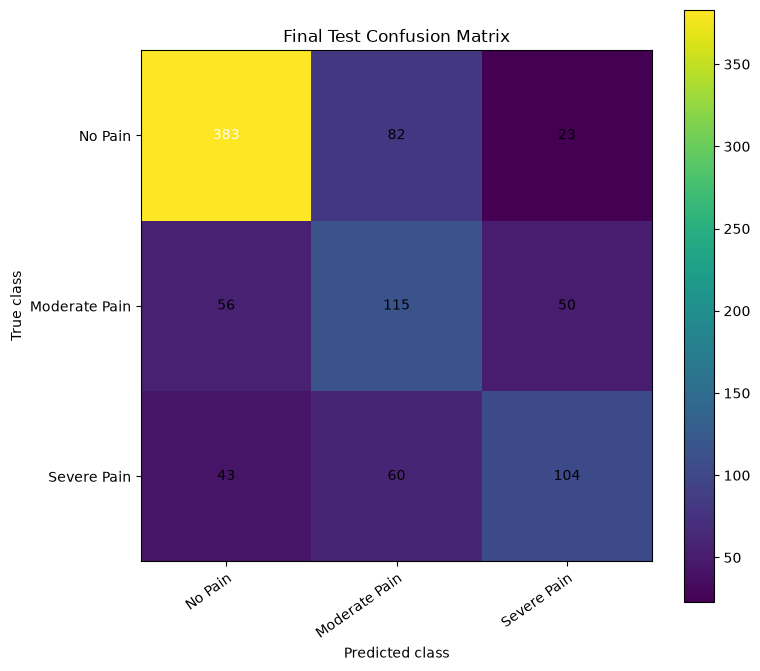

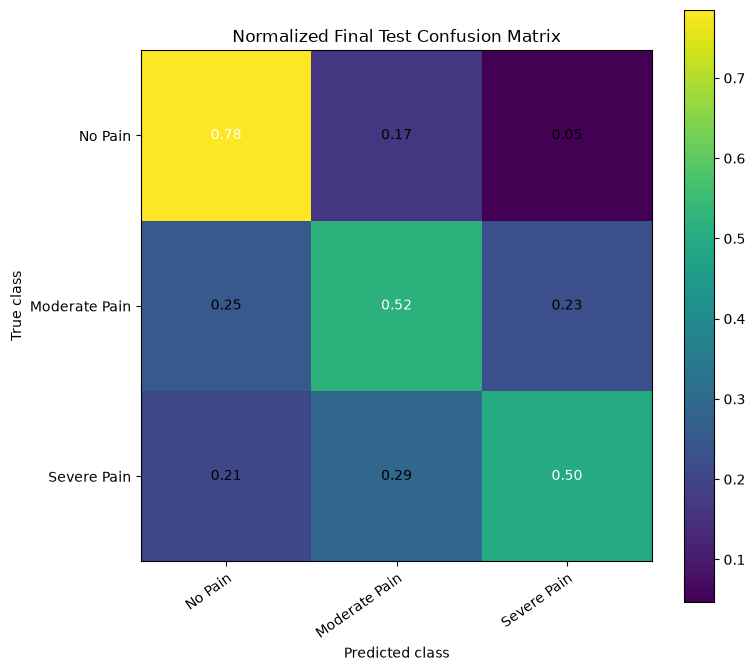

In [11]:
def plot_confusion_matrix(
    matrix: np.ndarray,
    class_names: list[str],
    title: str,
    output_path: Path,
    value_format: str,
) -> None:
    fig, axis = plt.subplots(
        figsize=(8, 7)
    )

    image = axis.imshow(
        matrix,
        interpolation="nearest",
    )

    axis.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted class",
        ylabel="True class",
        title=title,
    )

    plt.setp(
        axis.get_xticklabels(),
        rotation=35,
        ha="right",
        rotation_mode="anchor",
    )

    threshold = (
        matrix.max() / 2.0
        if matrix.size
        else 0.0
    )

    for row_index in range(
        matrix.shape[0]
    ):
        for column_index in range(
            matrix.shape[1]
        ):
            value = matrix[
                row_index,
                column_index,
            ]

            axis.text(
                column_index,
                row_index,
                format(value, value_format),
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
            )

    fig.colorbar(
        image,
        ax=axis,
    )

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


RAW_CM_FIGURE = (
    FIGURES_DIR
    / "test_confusion_matrix.png"
)

NORMALIZED_CM_FIGURE = (
    FIGURES_DIR
    / "normalized_test_confusion_matrix.png"
)

plot_confusion_matrix(
    matrix=confusion,
    class_names=CLASS_NAMES,
    title="Final Test Confusion Matrix",
    output_path=RAW_CM_FIGURE,
    value_format="d",
)

plot_confusion_matrix(
    matrix=normalized_confusion,
    class_names=CLASS_NAMES,
    title="Normalized Final Test Confusion Matrix",
    output_path=NORMALIZED_CM_FIGURE,
    value_format=".2f",
)

,count,mean,median,std,min,max
prediction_status,,,,,,
Correct,602,0.797638,0.837795,0.170983,0.353653,0.999825
Incorrect,314,0.647901,0.633079,0.156418,0.342878,0.976204


,dataset_index,image_path,horse_id,face_region,true_label,true_class,predicted_label,predicted_class,confidence,correct,unweighted_cross_entropy,probability_no_pain,probability_moderate_pain,probability_severe_pain
0,227,/home/uteam6/computer-vision-equine-grimace-sc...,M6,ears,1,Moderate Pain,0,No Pain,0.976204,False,4.548611,0.976204,0.010582,0.013214
1,747,/home/uteam6/computer-vision-equine-grimace-sc...,M7,ears,2,Severe Pain,0,No Pain,0.966371,False,4.168130,0.966371,0.018148,0.015481
2,252,/home/uteam6/computer-vision-equine-grimace-sc...,M6,ears,2,Severe Pain,0,No Pain,0.960593,False,4.398943,0.960593,0.027117,0.012290
3,251,/home/uteam6/computer-vision-equine-grimace-sc...,M6,ears,2,Severe Pain,0,No Pain,0.960268,False,4.130002,0.960268,0.023649,0.016083
4,327,/home/uteam6/computer-vision-equine-grimace-sc...,M6,eyes,0,No Pain,1,Moderate Pain,0.956754,False,3.252686,0.038670,0.956754,0.004576
5,250,/home/uteam6/computer-vision-equine-grimace-sc...,M6,ears,2,Severe Pain,0,No Pain,0.954284,False,3.452814,0.954284,0.014060,0.031656
6,232,/home/uteam6/computer-vision-equine-grimace-sc...,M6,ears,1,Moderate Pain,0,No Pain,0.953706,False,3.528484,0.953706,0.029349,0.016945
7,713,/home/uteam6/computer-vision-equine-grimace-sc...,M7,ears,1,Moderate Pain,0,No Pain,0.948823,False,3.811651,0.948823,0.022112,0.029065
8,485,/home/uteam6/computer-vision-equine-grimace-sc...,M6,mouth_nostrils,0,No Pain,1,Moderate Pain,0.946705,False,3.387905,0.033779,0.946705,0.019516
9,328,/home/uteam6/computer-vision-equine-grimace-sc...,M6,eyes,0,No Pain,1,Moderate Pain,0.943946,False,2.980740,0.050755,0.943946,0.005299


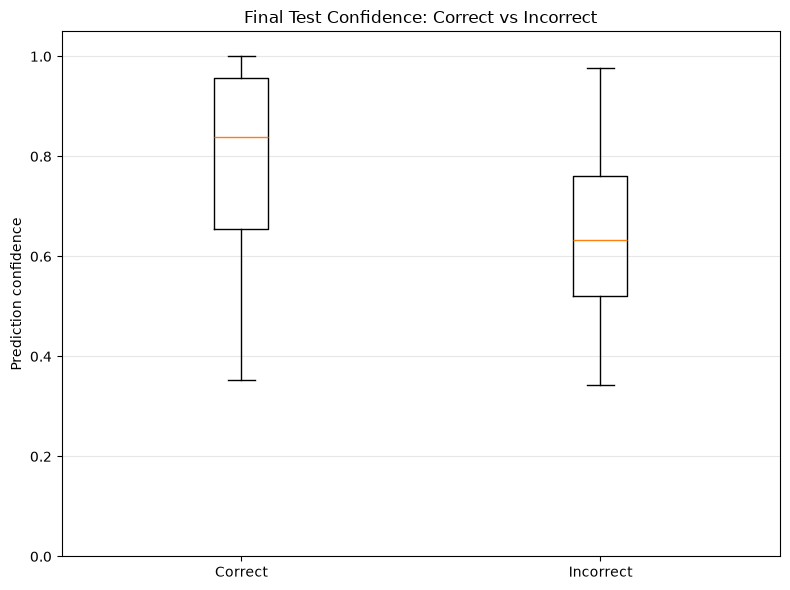

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/high_confidence_test_mistakes.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/figures/confidence_correct_vs_incorrect.png


In [12]:
HIGH_CONFIDENCE_THRESHOLD = 0.80

high_confidence_mistakes_df = (
    predictions_df.loc[
        (~predictions_df["correct"])
        & (
            predictions_df["confidence"]
            >= HIGH_CONFIDENCE_THRESHOLD
        )
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

HIGH_CONFIDENCE_MISTAKES_CSV = (
    FINAL_EVALUATION_DIR
    / "high_confidence_test_mistakes.csv"
)

high_confidence_mistakes_df.to_csv(
    HIGH_CONFIDENCE_MISTAKES_CSV,
    index=False,
)

confidence_summary_df = (
    predictions_df
    .assign(
        prediction_status=np.where(
            predictions_df["correct"],
            "Correct",
            "Incorrect",
        )
    )
    .groupby(
        "prediction_status"
    )["confidence"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
)

display(confidence_summary_df)
display(high_confidence_mistakes_df.head(20))

fig, axis = plt.subplots(
    figsize=(8, 6)
)

confidence_groups = [
    correct_confidences.to_numpy(),
    incorrect_confidences.to_numpy(),
]

axis.boxplot(
    confidence_groups,
    tick_labels=[
        "Correct",
        "Incorrect",
    ],
)

axis.set_ylabel(
    "Prediction confidence"
)

axis.set_title(
    "Final Test Confidence: Correct vs Incorrect"
)

axis.set_ylim(
    0.0,
    1.05,
)

axis.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

CONFIDENCE_FIGURE = (
    FIGURES_DIR
    / "confidence_correct_vs_incorrect.png"
)

fig.savefig(
    CONFIDENCE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {HIGH_CONFIDENCE_MISTAKES_CSV}")
print(f"Saved: {CONFIDENCE_FIGURE}")

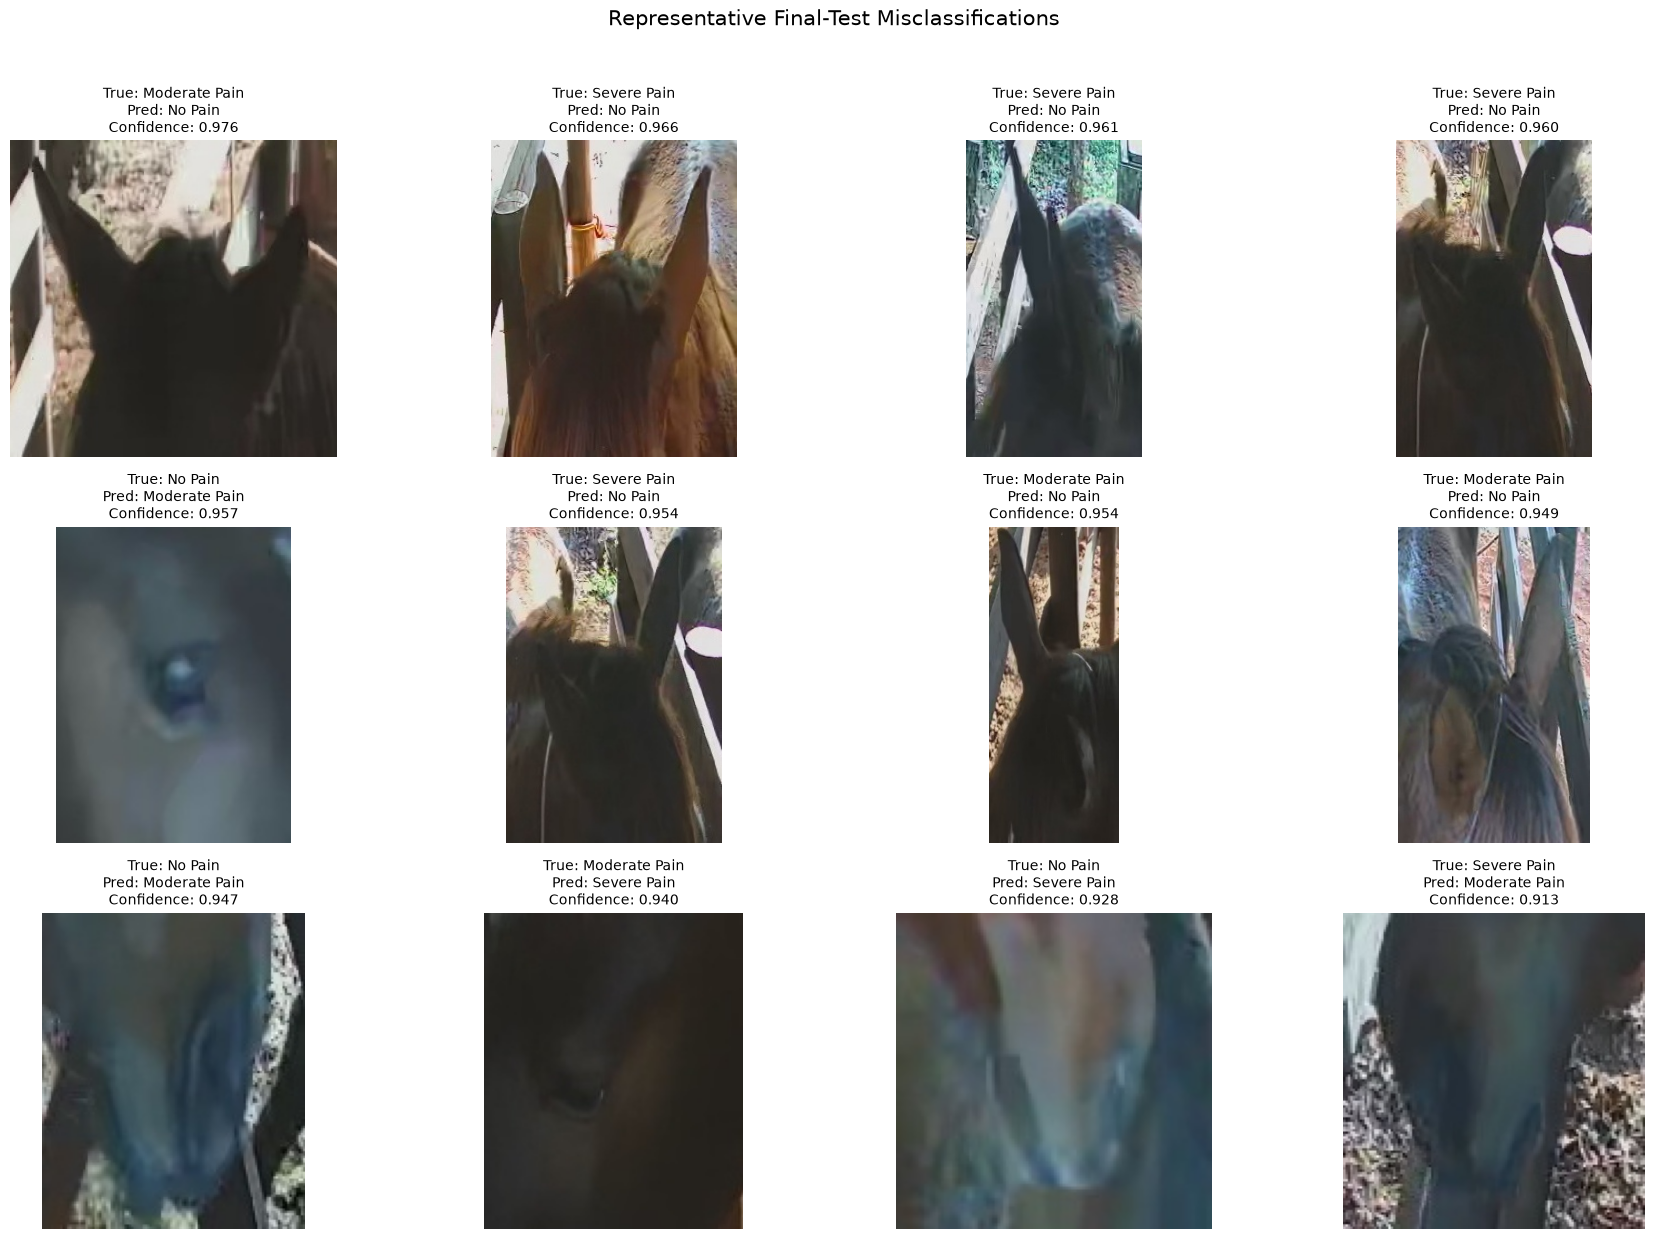

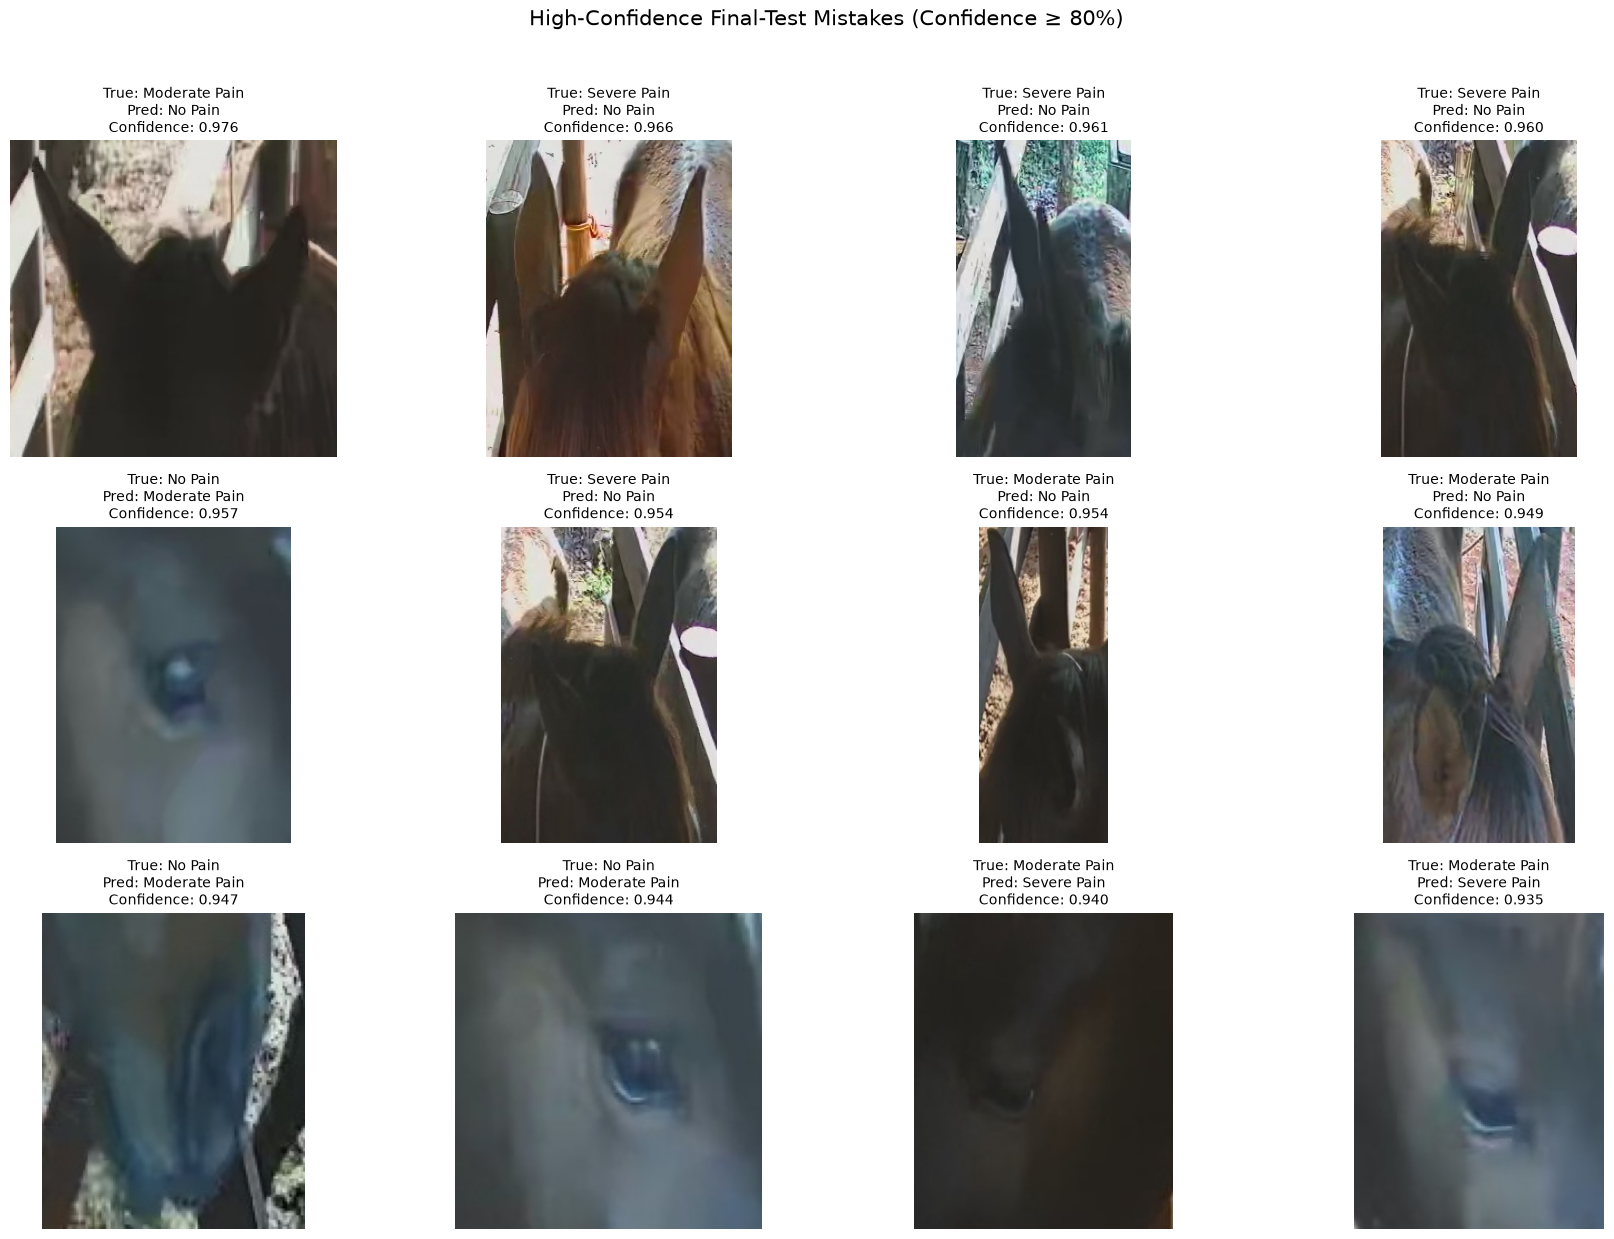

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/figures/misclassified_test_examples.png
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/figures/high_confidence_test_mistakes.png


In [13]:
def resolve_image_path(
    stored_path: Any,
) -> Path | None:
    if stored_path is None:
        return None

    path = Path(
        str(stored_path)
    )

    candidates = [
        path,
        PROJECT_ROOT / path,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


def select_diverse_errors(
    dataframe: pd.DataFrame,
    maximum_examples: int = 12,
) -> pd.DataFrame:
    errors = dataframe.loc[
        ~dataframe["correct"]
    ].copy()

    if errors.empty:
        return errors

    errors["confusion_direction"] = (
        errors["true_class"]
        + " → "
        + errors["predicted_class"]
    )

    selected_rows = []

    for _, group in errors.groupby(
        "confusion_direction",
        sort=True,
    ):
        selected_rows.append(
            group.sort_values(
                "confidence",
                ascending=False,
            ).iloc[0]
        )

    selected_df = pd.DataFrame(
        selected_rows
    )

    remaining_count = (
        maximum_examples
        - len(selected_df)
    )

    if remaining_count > 0:
        remaining = errors.loc[
            ~errors.index.isin(
                selected_df.index
            )
        ].sort_values(
            "confidence",
            ascending=False,
        )

        selected_df = pd.concat(
            [
                selected_df,
                remaining.head(
                    remaining_count
                ),
            ],
            axis=0,
        )

    return (
        selected_df
        .sort_values(
            "confidence",
            ascending=False,
        )
        .head(maximum_examples)
        .reset_index(drop=True)
    )


def plot_prediction_examples(
    examples_df: pd.DataFrame,
    output_path: Path,
    title: str,
    maximum_columns: int = 4,
) -> None:
    if examples_df.empty:
        print(
            f"No examples available for: {title}"
        )
        return

    number_of_examples = len(
        examples_df
    )

    columns = min(
        maximum_columns,
        number_of_examples,
    )

    rows = int(
        np.ceil(
            number_of_examples
            / columns
        )
    )

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            4.5 * columns,
            4.2 * rows,
        ),
        squeeze=False,
    )

    flattened_axes = axes.ravel()

    for axis, (_, example) in zip(
        flattened_axes,
        examples_df.iterrows(),
    ):
        image_path = resolve_image_path(
            example["image_path"]
        )

        if image_path is not None:
            with Image.open(image_path) as image:
                axis.imshow(
                    image.convert("RGB")
                )
        else:
            axis.text(
                0.5,
                0.5,
                "Image not found",
                ha="center",
                va="center",
            )

        axis.set_title(
            f"True: {example['true_class']}\n"
            f"Pred: {example['predicted_class']}\n"
            f"Confidence: {example['confidence']:.3f}",
            fontsize=10,
        )

        axis.axis("off")

    for axis in flattened_axes[
        number_of_examples:
    ]:
        axis.axis("off")

    fig.suptitle(
        title,
        fontsize=15,
    )

    fig.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


diverse_errors_df = select_diverse_errors(
    predictions_df,
    maximum_examples=12,
)

MISCLASSIFIED_FIGURE = (
    FIGURES_DIR
    / "misclassified_test_examples.png"
)

plot_prediction_examples(
    examples_df=diverse_errors_df,
    output_path=MISCLASSIFIED_FIGURE,
    title="Representative Final-Test Misclassifications",
)

HIGH_CONFIDENCE_FIGURE = (
    FIGURES_DIR
    / "high_confidence_test_mistakes.png"
)

plot_prediction_examples(
    examples_df=high_confidence_mistakes_df.head(12),
    output_path=HIGH_CONFIDENCE_FIGURE,
    title=(
        "High-Confidence Final-Test Mistakes "
        f"(Confidence ≥ {HIGH_CONFIDENCE_THRESHOLD:.0%})"
    ),
)

print(f"Saved: {MISCLASSIFIED_FIGURE}")

if not high_confidence_mistakes_df.empty:
    print(f"Saved: {HIGH_CONFIDENCE_FIGURE}")

In [14]:
def sha256_file(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as input_file:
        while True:
            chunk = input_file.read(
                chunk_size
            )

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


evaluation_timestamp = (
    datetime.now(timezone.utc)
    .isoformat()
)

checkpoint_sha256 = sha256_file(
    FINAL_CHECKPOINT
)

metadata_sha256 = sha256_file(
    FINAL_METADATA
)

test_csv_sha256 = sha256_file(
    TEST_CSV
)

FINAL_MODEL_SNAPSHOT_JSON = (
    FINAL_EVALUATION_DIR
    / "final_model_snapshot.json"
)

PHASE_10_MANIFEST_JSON = (
    FINAL_EVALUATION_DIR
    / "phase_10_manifest.json"
)

final_model_snapshot = {
    "evaluation_timestamp_utc": (
        evaluation_timestamp
    ),
    "canonical_checkpoint": str(
        FINAL_CHECKPOINT.relative_to(
            PROJECT_ROOT
        )
    ),
    "canonical_metadata": str(
        FINAL_METADATA.relative_to(
            PROJECT_ROOT
        )
    ),
    "checkpoint_sha256": (
        checkpoint_sha256
    ),
    "metadata_sha256": (
        metadata_sha256
    ),
    "resolved_architecture": (
        MODEL_FAMILY
    ),
    "resolved_training_mode": (
        TRAINING_MODE
    ),
    "resolved_num_classes": (
        NUM_CLASSES
    ),
    "resolved_class_names": (
        CLASS_NAMES
    ),
    "resolved_dropout": (
        DROPOUT
    ),
    "resolved_image_size": (
        IMAGE_SIZE
    ),
    "resolved_resize_size": (
        RESIZE_SIZE
    ),
    "resolved_class_weights": (
        CLASS_WEIGHTS_LIST
    ),
    "source_metadata": metadata,
}

phase_10_manifest = {
    "phase": 10,
    "name": (
        "Final Untouched Test Evaluation"
    ),
    "evaluation_timestamp_utc": (
        evaluation_timestamp
    ),
    "test_set_used": True,
    "training_performed": False,
    "tuning_performed": False,
    "model_comparison_performed": False,
    "threshold_changed": False,
    "random_augmentation_used": False,
    "shuffle": False,
    "model_eval_mode": True,
    "inference_mode": True,
    "primary_selection_metric": (
        "macro_f1"
    ),
    "test_csv": str(
        TEST_CSV.relative_to(
            PROJECT_ROOT
        )
    ),
    "test_csv_sha256": (
        test_csv_sha256
    ),
    "test_sample_count": int(
        total_samples
    ),
    "checkpoint_sha256": (
        checkpoint_sha256
    ),
    "metadata_sha256": (
        metadata_sha256
    ),
    "device": str(DEVICE),
    "gpu": (
        torch.cuda.get_device_name(0)
        if DEVICE.type == "cuda"
        else None
    ),
    "python_version": (
        platform.python_version()
    ),
    "platform": (
        platform.platform()
    ),
    "torch_version": (
        torch.__version__
    ),
    "sklearn_version": (
        sklearn.__version__
    ),
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "preprocessing": {
        "resize": [
            RESIZE_SIZE,
            RESIZE_SIZE,
        ],
        "center_crop": IMAGE_SIZE,
        "to_tensor": True,
        "normalization_mean": (
            IMAGENET_MEAN
        ),
        "normalization_std": (
            IMAGENET_STD
        ),
    },
    "loss_reporting": {
        "primary": (
            "class_weighted_cross_entropy"
        ),
        "secondary": (
            "unweighted_cross_entropy"
        ),
    },
    "high_confidence_threshold": (
        HIGH_CONFIDENCE_THRESHOLD
    ),
    "final_metrics": final_metrics,
}

with FINAL_MODEL_SNAPSHOT_JSON.open(
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        final_model_snapshot,
        output_file,
        indent=4,
    )

with PHASE_10_MANIFEST_JSON.open(
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        phase_10_manifest,
        output_file,
        indent=4,
    )

print(f"Checkpoint SHA-256: {checkpoint_sha256}")
print(f"Test CSV SHA-256:    {test_csv_sha256}")
print(f"Saved: {FINAL_MODEL_SNAPSHOT_JSON}")
print(f"Saved: {PHASE_10_MANIFEST_JSON}")

Checkpoint SHA-256: cda1c2e1e4f3646a43566f5baef00dcaf44272ffa543d9352483b9fdd4e2b65b
Test CSV SHA-256:    c5a671fd030e797a2e79be115fc144714cc83c54b4be381ebcf0c34829440d09
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/final_model_snapshot.json
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/phase_10_manifest.json


In [15]:
strongest_class_row = (
    per_class_metrics_df
    .sort_values(
        "recall",
        ascending=False,
    )
    .iloc[0]
)

weakest_class_row = (
    per_class_metrics_df
    .sort_values(
        "recall",
        ascending=True,
    )
    .iloc[0]
)

number_of_errors = int(
    (~predictions_df["correct"]).sum()
)

high_confidence_error_count = int(
    len(high_confidence_mistakes_df)
)

summary = f'''
## Final untouched test results

The canonical **{MODEL_FAMILY}** model was evaluated once on
**{total_samples:,} untouched test images**.

| Metric | Final test result |
|---|---:|
| Weighted cross-entropy loss | {WEIGHTED_TEST_LOSS:.4f} |
| Unweighted cross-entropy loss | {UNWEIGHTED_TEST_LOSS:.4f} |
| Accuracy | {accuracy:.4f} |
| Macro precision | {macro_precision:.4f} |
| Macro recall | {macro_recall:.4f} |
| **Macro F1** | **{macro_f1:.4f}** |
| Weighted F1 | {weighted_f1:.4f} |
| Mean prediction confidence | {mean_confidence:.4f} |

The highest per-class recall was obtained for
**{strongest_class_row['class_name']}**
({strongest_class_row['recall']:.4f}).

The lowest per-class recall was obtained for
**{weakest_class_row['class_name']}**
({weakest_class_row['recall']:.4f}).

The model made **{number_of_errors}** incorrect predictions.
Of these, **{high_confidence_error_count}** had confidence greater than or equal to
{HIGH_CONFIDENCE_THRESHOLD:.0%}.

These results are now frozen as the project's final reported test performance.
They must not be used to retrain the model, change preprocessing, tune
hyperparameters, select another checkpoint, or alter decision thresholds.
'''

display(
    Markdown(summary)
)

SUMMARY_PATH = (
    FINAL_EVALUATION_DIR
    / "phase_10_summary.md"
)

SUMMARY_PATH.write_text(
    summary.strip() + "\n",
    encoding="utf-8",
)

print(f"Saved: {SUMMARY_PATH}")


## Final untouched test results

The canonical **resnet18** model was evaluated once on
**916 untouched test images**.

| Metric | Final test result |
|---|---:|
| Weighted cross-entropy loss | 0.9005 |
| Unweighted cross-entropy loss | 0.7680 |
| Accuracy | 0.6572 |
| Macro precision | 0.6099 |
| Macro recall | 0.6025 |
| **Macro F1** | **0.6042** |
| Weighted F1 | 0.6592 |
| Mean prediction confidence | 0.7463 |

The highest per-class recall was obtained for
**No Pain**
(0.7848).

The lowest per-class recall was obtained for
**Severe Pain**
(0.5024).

The model made **314** incorrect predictions.
Of these, **69** had confidence greater than or equal to
80%.

These results are now frozen as the project's final reported test performance.
They must not be used to retrain the model, change preprocessing, tune
hyperparameters, select another checkpoint, or alter decision thresholds.


Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_evaluation/phase_10_summary.md


In [16]:
expected_outputs = [
    FINAL_EVALUATION_DIR
    / "final_test_metrics.json",
    FINAL_EVALUATION_DIR
    / "final_test_metrics.csv",
    FINAL_EVALUATION_DIR
    / "classification_report.csv",
    FINAL_EVALUATION_DIR
    / "per_class_metrics.csv",
    FINAL_EVALUATION_DIR
    / "test_predictions.csv",
    FINAL_EVALUATION_DIR
    / "test_confusion_matrix.csv",
    FINAL_EVALUATION_DIR
    / "normalized_test_confusion_matrix.csv",
    FINAL_EVALUATION_DIR
    / "high_confidence_test_mistakes.csv",
    FINAL_EVALUATION_DIR
    / "final_model_snapshot.json",
    FINAL_EVALUATION_DIR
    / "phase_10_manifest.json",
    FINAL_EVALUATION_DIR
    / "phase_10_summary.md",
    FIGURES_DIR
    / "test_confusion_matrix.png",
    FIGURES_DIR
    / "normalized_test_confusion_matrix.png",
    FIGURES_DIR
    / "misclassified_test_examples.png",
    FIGURES_DIR
    / "confidence_correct_vs_incorrect.png",
]

if not high_confidence_mistakes_df.empty:
    expected_outputs.append(
        FIGURES_DIR
        / "high_confidence_test_mistakes.png"
    )

verification_rows = []

for output_path in expected_outputs:
    verification_rows.append(
        {
            "output": str(
                output_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": output_path.exists(),
            "size_bytes": (
                output_path.stat().st_size
                if output_path.exists()
                else 0
            ),
        }
    )

verification_df = pd.DataFrame(
    verification_rows
)

display(verification_df)

missing_outputs = verification_df.loc[
    ~verification_df["exists"],
    "output",
].tolist()

assert not missing_outputs, (
    "Missing expected Phase 10 outputs: "
    f"{missing_outputs}"
)

print(
    "\nPhase 10 completed successfully. "
    "The final test result is frozen."
)

,output,exists,size_bytes
0,results/final_evaluation/final_test_metrics.json,True,643
1,results/final_evaluation/final_test_metrics.csv,True,521
2,results/final_evaluation/classification_report...,True,488
3,results/final_evaluation/per_class_metrics.csv,True,268
4,results/final_evaluation/test_predictions.csv,True,223148
5,results/final_evaluation/test_confusion_matrix...,True,144
6,results/final_evaluation/normalized_test_confu...,True,288
7,results/final_evaluation/high_confidence_test_...,True,17103
8,results/final_evaluation/final_model_snapshot....,True,2657
9,results/final_evaluation/phase_10_manifest.json,True,2325



Phase 10 completed successfully. The final test result is frozen.
